In [ ]:
# ==============================================================
# Cell 1 — Imports & config
# ==============================================================
from pathlib import Path
import numpy as np
import laspy
import yaml
import pandas as pd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------

# Fichier YAML des LCP pointés dans le nuage MLS avec dérive
LCP_YAML = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP/lcp_outage.yml")

# Dossier contenant les blocs MLS ajustés sur GCP (nuages de référence)
REF_BLOCS_DIR = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP")

# Dossier contenant les nuages MLS avec dérive (outage)
# Dossiers à comparer
# AIRINS
# DIRS = {
#     "Outage":   Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/merged/ALL"),
#     "F2B":      Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/georef_F2B/merged/ALL"),
#     "Combined": Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/georef_COMBINED/merged/ALL"),
# }

# APX
DIRS = {
    "Outage":   Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/georef_F2B/merged/ALL"),
    "F2B":      Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/georef_F2B/merged/ALL"),
    "Combined": Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/georef_COMBINED/merged/ALL"),
}
# Rayon de recherche densité (m) et tolérance Z (m)
DENSITY_RADIUS = 0.50
DENSITY_DZ     = 0.05

# Rayon de recherche correspondance (m) — pour trouver le point le plus proche dans le bloc ref
MATCH_RADIUS   = 5.0

# scanner_src VUX
VUX_SRC = 2

In [14]:
# ==============================================================
# Cell 2 — Charger les LCP depuis le YAML
# ==============================================================

with open(LCP_YAML, "r") as f:
    lcp_raw = yaml.safe_load(f)

lcps = pd.DataFrame(lcp_raw["lcps"])
lcps = lcps.set_index("id")

print(f"{len(lcps)} LCPs chargés\n")
display(lcps)

8 LCPs chargés



,description,gps_time,x,y,z
id,,,,,
LCP01,marquage sol,315659.459576,2.533286e+06,1.155104e+06,462.988007
LCP02,bouche egout,315712.474327,2.533259e+06,1.155030e+06,462.362000
LCP03,bouche egout,315742.343422,2.533259e+06,1.155030e+06,462.389008
LCP04,marquage sol,315761.046630,2.533263e+06,1.155090e+06,463.408997
LCP05,lampadaire pied,315810.311700,2.533227e+06,1.155117e+06,463.656006
LCP06,marquage sol coin,315822.334268,2.533238e+06,1.155167e+06,464.398987
LCP07,marquage sol coin,316057.153545,2.533239e+06,1.155169e+06,464.015015
LCP08,bouche egout,315842.746895,2.533265e+06,1.155193e+06,464.609009


In [15]:
# ==============================================================
# Cell 3 — Localisation des LCP dans les nuages outage
#           Scan direct de tous les fichiers du dossier
# ==============================================================

def find_point_by_gpstime(las_path: Path, gps_time: float, xyz_ref: np.ndarray,
                           tol_t: float = 0.5,
                           tol_xyz: float = 5.0):
    best_dist = np.inf
    best_result = None

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            t = np.asarray(chunk.gps_time, dtype=np.float64)

            # Pas d'early exit — le fichier merged n'est pas forcément trié
            mask_t = np.abs(t - gps_time) < tol_t
            if not np.any(mask_t):
                continue

            x = np.asarray(chunk.x, dtype=np.float64)[mask_t]
            y = np.asarray(chunk.y, dtype=np.float64)[mask_t]
            z = np.asarray(chunk.z, dtype=np.float64)[mask_t]
            xyz = np.column_stack([x, y, z])

            dists = np.linalg.norm(xyz - xyz_ref, axis=1)
            best  = np.argmin(dists)

            if dists[best] < best_dist:
                best_dist = dists[best]
                best_result = {
                    "xyz_found":      xyz[best],
                    "dist":           float(dists[best]),
                    "gps_time_found": float(t[mask_t][best]),
                    "file":           las_path.name,
                }

    if best_result is not None and best_dist <= tol_xyz:
        return best_result
    return None

# ------------------------------------------------------------
df_check_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}  —  {source_dir}\n{'='*50}")
    outage_files = sorted(source_dir.glob("*.las")) + sorted(source_dir.glob("*.laz"))
    print(f"{len(outage_files)} fichiers\n")

    check_rows = []
    for lcp_id, row in lcps.iterrows():
        xyz_ref = np.array([row["x"], row["y"], row["z"]], dtype=np.float64)
        gps_t   = float(row["gps_time"])
        print(f"  {lcp_id} (t={gps_t:.3f})... ", end="", flush=True)

        found = None
        for las_path in outage_files:
            res = find_point_by_gpstime(las_path, gps_t, xyz_ref)
            if res is not None:
                found = res
                break

        if found is None:
            print("NOT FOUND")
            check_rows.append({"id": lcp_id, "gps_time": gps_t,
                               "found": False, "status": "NOT FOUND",
                               "file": None, "dist_to_lcp": None})
        else:
            print(f"OK  dist={found['dist']:.3f}m  [{found['file']}]")
            check_rows.append({"id": lcp_id, "gps_time": gps_t,
                               "found": True, "status": "OK",
                               "xyz_found": found["xyz_found"],
                               "dist_to_lcp": found["dist"],
                               "file": found["file"]})

    df_check_all[label] = pd.DataFrame(check_rows).set_index("id")
    n_ok = df_check_all[label]["found"].sum()
    print(f"\n{n_ok}/{len(lcps)} LCP trouvés")


Outage  —  /media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/merged/ALL
8 fichiers

  LCP01 (t=315659.460)... OK  dist=0.000m  [merged_1000_VUX_PUCK.las]
  LCP02 (t=315712.474)... OK  dist=0.000m  [merged_2000_VUX_PUCK.las]
  LCP03 (t=315742.343)... OK  dist=0.000m  [merged_3000_VUX_PUCK.las]
  LCP04 (t=315761.047)... OK  dist=0.000m  [merged_3000_VUX_PUCK.las]
  LCP05 (t=315810.312)... OK  dist=0.000m  [merged_4000_VUX_PUCK.las]
  LCP06 (t=315822.334)... OK  dist=0.000m  [merged_4000_VUX_PUCK.las]
  LCP07 (t=316057.154)... OK  dist=0.000m  [merged_8000_VUX_PUCK.las]
  LCP08 (t=315842.747)... OK  dist=0.000m  [merged_5000_VUX_PUCK.las]

8/8 LCP trouvés

F2B  —  /media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/georef_F2B/merged/ALL
8 fichiers

  LCP01 (t=315659.460)... OK  dist=0.033m  [merged_1000_VUX_PUCK.las]
  LCP02 (t=315712.474)... OK  dist=0.254m  [merged_2000_VUX_PUCK.las]
  LCP03 (t=315742.343)... OK  dist=0.284m  [merged_3000_VUX_PUCK.las]
  LCP

In [16]:
# ==============================================================
# Cell 4 — Densité de points VUX au sol autour de chaque LCP
#           Cylindre R=50cm, dz=±5cm
# ==============================================================

def density_around_point(las_path: Path, xyz_center: np.ndarray,
                          radius: float = 0.5, dz: float = 0.05) -> dict:
    x0, y0, z0 = xyz_center
    count = 0

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            z = np.asarray(chunk.z, dtype=np.float64)
            mask_z = np.abs(z - z0) < dz
            if not np.any(mask_z):
                continue

            x = np.asarray(chunk.x, dtype=np.float64)
            y = np.asarray(chunk.y, dtype=np.float64)
            dx = x[mask_z] - x0
            dy = y[mask_z] - y0
            count += int((dx**2 + dy**2 <= radius**2).sum())

    area = np.pi * radius**2
    return {"n_pts": count, "density_m2": round(count / area, 1)}


print(f"Densité dans cylindre R={DENSITY_RADIUS}m, dz=±{DENSITY_DZ}m\n")

df_density_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    df_check = df_check_all[label]

    density_rows = []
    for lcp_id, row in df_check[df_check["found"]].iterrows():
        xyz = np.array(row["xyz_found"])
        fname = row["file"]
        print(f"  {lcp_id} [{fname}]... ", end="", flush=True)

        d = density_around_point(source_dir / fname, xyz, DENSITY_RADIUS, DENSITY_DZ)
        density_rows.append({"id": lcp_id, **d})
        print(f"{d['n_pts']} pts  ->  {d['density_m2']} pts/m²")

    df_density_all[label] = pd.DataFrame(density_rows).set_index("id")
    print(f"\nDensité médiane : {df_density_all[label]['density_m2'].median():.1f} pts/m²")
    display(df_density_all[label])

Densité dans cylindre R=0.5m, dz=±0.05m


Outage
  LCP01 [merged_1000_VUX_PUCK.las]... 10983 pts  ->  13984.0 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4894 pts  ->  6231.2 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 9786 pts  ->  12459.9 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 23031 pts  ->  29324.0 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 3215 pts  ->  4093.5 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 3915 pts  ->  4984.7 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4535 pts  ->  5774.1 pts/m²
  LCP08 [merged_5000_VUX_PUCK.las]... 41746 pts  ->  53152.7 pts/m²

Densité médiane : 9345.5 pts/m²


,n_pts,density_m2
id,,
LCP01,10983,13984.0
LCP02,4894,6231.2
LCP03,9786,12459.9
LCP04,23031,29324.0
LCP05,3215,4093.5
LCP06,3915,4984.7
LCP07,4535,5774.1
LCP08,41746,53152.7



F2B
  LCP01 [merged_1000_VUX_PUCK.las]... 11220 pts  ->  14285.7 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4753 pts  ->  6051.7 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 10002 pts  ->  12734.9 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 23930 pts  ->  30468.6 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 941 pts  ->  1198.1 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 5516 pts  ->  7023.2 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4459 pts  ->  5677.4 pts/m²
  LCP08 [merged_5000_VUX_PUCK.las]... 33099 pts  ->  42143.0 pts/m²

Densité médiane : 9879.0 pts/m²


,n_pts,density_m2
id,,
LCP01,11220,14285.7
LCP02,4753,6051.7
LCP03,10002,12734.9
LCP04,23930,30468.6
LCP05,941,1198.1
LCP06,5516,7023.2
LCP07,4459,5677.4
LCP08,33099,42143.0



Combined
  LCP01 [merged_1000_VUX_PUCK.las]... 11238 pts  ->  14308.7 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4658 pts  ->  5930.7 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 9961 pts  ->  12682.7 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 23858 pts  ->  30376.9 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 505 pts  ->  643.0 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 5959 pts  ->  7587.2 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4399 pts  ->  5601.0 pts/m²
  LCP08 [merged_5000_VUX_PUCK.las]... 31769 pts  ->  40449.5 pts/m²

Densité médiane : 10135.0 pts/m²


,n_pts,density_m2
id,,
LCP01,11238,14308.7
LCP02,4658,5930.7
LCP03,9961,12682.7
LCP04,23858,30376.9
LCP05,505,643.0
LCP06,5959,7587.2
LCP07,4399,5601.0
LCP08,31769,40449.5


In [17]:
# ==============================================================
# Cell 5 — Charger les blocs ref ajustés GCP et trouver
#           le point correspondant à chaque LCP
# ==============================================================

REF_FILES = sorted(REF_BLOCS_DIR.glob("*.las")) + sorted(REF_BLOCS_DIR.glob("*.laz"))
print(f"{len(REF_FILES)} blocs ref dans {REF_BLOCS_DIR}\n")

LEAP_SECONDS = 18.0  # LCP GPS -> blocs ref UTC

def find_nearest_in_ref(las_path: Path, gps_time: float, xyz_outage: np.ndarray,
                         tol_t: float = 0.5, tol_xyz: float = 5.0,
                         time_offset: float = 0.0):
    """
    time_offset : appliqué au gps_time avant la recherche (ex: -18.0)
    """
    t_search = gps_time + time_offset
    best_dist = np.inf
    best_result = None

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            t = np.asarray(chunk.gps_time, dtype=np.float64)
            mask_t = np.abs(t - t_search) < tol_t
            if not np.any(mask_t):
                continue

            x = np.asarray(chunk.x, dtype=np.float64)[mask_t]
            y = np.asarray(chunk.y, dtype=np.float64)[mask_t]
            z = np.asarray(chunk.z, dtype=np.float64)[mask_t]
            xyz = np.column_stack([x, y, z])

            dists = np.linalg.norm(xyz - xyz_outage, axis=1)
            best  = np.argmin(dists)

            if dists[best] < best_dist:
                best_dist = dists[best]
                best_result = {
                    "xyz_ref":  xyz[best],
                    "dist_3d":  float(dists[best]),
                    "dx": float(xyz[best, 0] - xyz_outage[0]),
                    "dy": float(xyz[best, 1] - xyz_outage[1]),
                    "dz": float(xyz[best, 2] - xyz_outage[2]),
                    "file_ref": las_path.name,
                }

    if best_result is not None and best_dist <= tol_xyz:
        return best_result
    return None

t0_outage = lcps["gps_time"].min()  # premier timestamp = t=0 dans l'outage

df_match_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    df_check = df_check_all[label]

    match_rows = []
    for lcp_id, row in df_check[df_check["found"]].iterrows():
        xyz_out = np.array(row["xyz_found"])
        gps_t   = float(row["gps_time"])
        t_in    = gps_t - t0_outage
        print(f"  {lcp_id} (t+{t_in:.1f}s)... ", end="", flush=True)

        found = None
        for ref_path in REF_FILES:
            res = find_nearest_in_ref(ref_path, gps_t, xyz_out,
                                       time_offset=-LEAP_SECONDS)
            if res is not None:
                if found is None or res["dist_3d"] < found["dist_3d"]:
                    found = res

        if found is None:
            print("NO MATCH")
            match_rows.append({"id": lcp_id, "gps_time": gps_t, "t_in_outage": t_in,
                               "dist_3d": None, "dx": None, "dy": None, "dz": None,
                               "dist_2d": None, "file_ref": None})
        else:
            d2d = np.sqrt(found["dx"]**2 + found["dy"]**2)
            print(f"dXY={d2d:.4f}m  dZ={found['dz']:.4f}m  d3D={found['dist_3d']:.4f}m")
            match_rows.append({"id": lcp_id, "gps_time": gps_t, "t_in_outage": t_in,
                               "dist_3d": found["dist_3d"], "dx": found["dx"],
                               "dy": found["dy"], "dz": found["dz"],
                               "dist_2d": d2d, "file_ref": found["file_ref"]})

    df_match_all[label] = pd.DataFrame(match_rows).set_index("id")

2 blocs ref dans /home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP


Outage
  LCP01 (t+0.0s)... dXY=0.0041m  dZ=-0.0680m  d3D=0.0681m
  LCP02 (t+53.0s)... dXY=0.0122m  dZ=-0.2980m  d3D=0.2983m
  LCP03 (t+82.9s)... dXY=0.0058m  dZ=-0.3330m  d3D=0.3331m
  LCP04 (t+101.6s)... dXY=0.0237m  dZ=-0.3490m  d3D=0.3498m
  LCP05 (t+150.9s)... dXY=0.3068m  dZ=0.0950m  d3D=0.3212m
  LCP06 (t+162.9s)... dXY=0.4457m  dZ=-0.4070m  d3D=0.6035m
  LCP07 (t+397.7s)... dXY=0.0071m  dZ=-0.0760m  d3D=0.0763m
  LCP08 (t+183.3s)... dXY=0.0300m  dZ=-0.5530m  d3D=0.5538m

F2B
  LCP01 (t+0.0s)... dXY=0.0028m  dZ=-0.0370m  d3D=0.0371m
  LCP02 (t+53.0s)... dXY=0.0117m  dZ=-0.0450m  d3D=0.0465m
  LCP03 (t+82.9s)... dXY=0.0094m  dZ=-0.0490m  d3D=0.0499m
  LCP04 (t+101.6s)... dXY=0.0022m  dZ=-0.0460m  d3D=0.0461m
  LCP05 (t+150.9s)... dXY=0.0691m  dZ=-0.1090m  d3D=0.1291m
  LCP06 (t+162.9s)... dXY=0.1718m  dZ=-0.0530m  d3D=0.1798m
  LCP07 (t+397.7s)... dXY=0.0072m  dZ=-0.0440m  d3D=0.0446m
  LCP08 (t+183.3s)... 

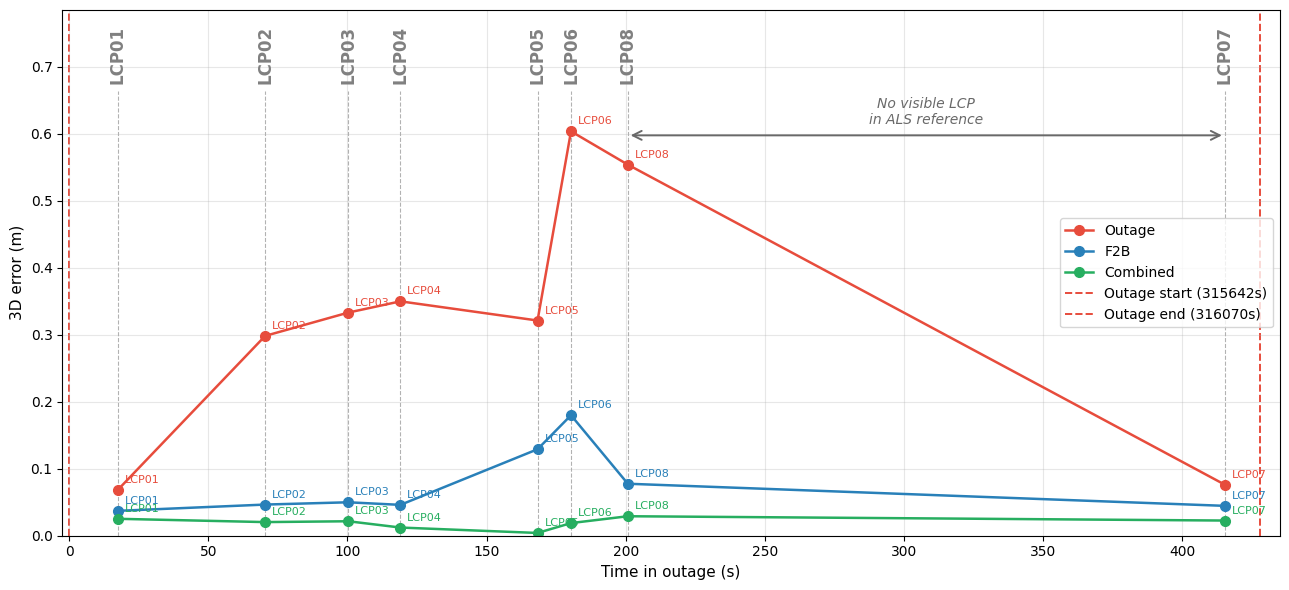


--- Summary ---
  Outage      RMSE=0.3720m   Max=0.6035m (LCP06)
  F2B         RMSE=0.0902m   Max=0.1798m (LCP06)
  Combined    RMSE=0.0206m   Max=0.0291m (LCP08)


In [20]:
# ==============================================================
# Cell 6 — Visualisation erreur 3D vs temps dans l'outage
# ==============================================================
T_OUTAGE_START_GPS = 315642.0
T_OUTAGE_END_GPS   = 316070.0
T_OUTAGE_DUR       = T_OUTAGE_END_GPS - T_OUTAGE_START_GPS
COLORS = {"Outage": "#e74c3c", "F2B": "#2980b9", "Combined": "#27ae60"}

fig, ax = plt.subplots(figsize=(13, 6))

# --- Courbes ---
for label, df_match in df_match_all.items():
    df_plot = df_match.dropna(subset=["dist_3d"]).copy()
    df_plot["t_in_outage"] = df_plot["gps_time"] - T_OUTAGE_START_GPS
    df_plot = df_plot.sort_values("t_in_outage")
    ax.plot(df_plot["t_in_outage"], df_plot["dist_3d"],
            "o-", color=COLORS[label], linewidth=1.8, markersize=7, label=label)
    for i, row in df_plot.iterrows():
        ax.annotate(i, (row["t_in_outage"], row["dist_3d"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8,
                    color=COLORS[label])

# --- ylim ---
y_max = max(
    df_match.dropna(subset=["dist_3d"])["dist_3d"].max()
    for df_match in df_match_all.values()
)
Y_TOP      = y_max * 1.3   # plus de place en haut
Y_LINE_TOP = y_max * 1.10   # traits gris jusqu'ici
Y_TEXT     = Y_LINE_TOP + 0.01
ax.set_ylim(bottom=0, top=Y_TOP)

# --- Lignes verticales grises par LCP ---
first_label = list(df_match_all.keys())[0]
df_lcp = df_match_all[first_label].dropna(subset=["dist_3d"]).copy()
df_lcp["t_in_outage"] = df_lcp["gps_time"] - T_OUTAGE_START_GPS
df_lcp = df_lcp.sort_values("t_in_outage")

lcp_times = df_lcp["t_in_outage"].values
lcp_names = df_lcp.index.tolist()

for lcp_name, t in zip(lcp_names, lcp_times):
    ax.plot([t, t], [0, Y_LINE_TOP],
            color="grey", linewidth=0.8, linestyle="--", alpha=0.6, zorder=0)
    ax.text(t, Y_TEXT, lcp_name,
            rotation=90, fontsize=12, color="grey",
            ha="center", va="bottom", fontweight="bold")

# --- Double flèche "No visible LCP in LAS data" entre avant-dernier et dernier LCP ---
if len(lcp_times) >= 2:
    t_start_arrow = lcp_times[-2]
    t_end_arrow   = lcp_times[-1]
    t_mid_arrow   = (t_start_arrow + t_end_arrow) / 2
    y_arrow       = Y_LINE_TOP * 0.9

    ax.annotate("", xy=(t_end_arrow, y_arrow), xytext=(t_start_arrow, y_arrow),
                arrowprops=dict(arrowstyle="<->", color="dimgrey",
                                lw=1.4, mutation_scale=16))
    ax.text(t_mid_arrow, y_arrow + 0.012,
            "No visible LCP\nin ALS reference",
            ha="center", va="bottom", fontsize=10,
            color="dimgrey", style="italic")

# --- Début et fin outage en rouge ---
ax.axvline(x=0,            color="#e74c3c", linewidth=1.4, linestyle="--",
           label=f"Outage start ({T_OUTAGE_START_GPS:.0f}s)", zorder=1)
ax.axvline(x=T_OUTAGE_DUR, color="#e74c3c", linewidth=1.4, linestyle="--",
           label=f"Outage end ({T_OUTAGE_END_GPS:.0f}s)", zorder=1)

ax.set_xlabel("Time in outage (s)", fontsize=11)
ax.set_ylabel("3D error (m)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/LCP_AIRINS_Z3_ECCR.png", dpi=400)
plt.show()

# --- Tableau récap ---
print("\n--- Summary ---")
for label, df_match in df_match_all.items():
    df_plot = df_match.dropna(subset=["dist_3d"])
    rmse  = np.sqrt((df_plot["dist_3d"]**2).mean())
    max_e = df_plot["dist_3d"].max()
    print(f"  {label:10s}  RMSE={rmse:.4f}m   Max={max_e:.4f}m ({df_plot['dist_3d'].idxmax()})")